# 01 Univariate Distribution Analysis

วัตถุประสงค์: สำรวจการกระจายของตัวแปรสำคัญรายตัว (single-variable behavior) เพื่อเตรียม insight ก่อนทำ bivariate/multivariate EDA

> This notebook focuses on:
- Tenure distribution
- Payment method distribution
- Monthly/Total charge distribution
- Quick churn context checks


## Setup and Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use processed dataset from data preparation phase
df = pd.read_csv('../../data/processed/telco_customer_churn_clean.csv')

## 1. Tenure Analysis

In [3]:
print(df["tenure"].unique())

print("\n")

print("Min Tenure:", df["tenure"].min())
print("Max Tenure:", df["tenure"].max())

[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


Min Tenure: 0
Max Tenure: 72


### Tenure = 0 Analysis: Do new customers churn immediately?

In [4]:
# Check do 0 Tenure always Churn
df[df["tenure"] == df["tenure"].min()]["Churn"] \
    .value_counts().reindex(["Yes", "No"], fill_value=0)

Churn
Yes     0
No     11
Name: count, dtype: int64

**Insight:** à¸„à¹ˆà¸² `tenure = 0` à¹„à¸¡à¹ˆà¹„à¸”à¹‰à¸«à¸¡à¸²à¸¢à¸„à¸§à¸²à¸¡à¸§à¹ˆà¸²à¸¥à¸¹à¸à¸„à¹‰à¸² churn à¸—à¸¸à¸à¸„à¸™à¸—à¸±à¸™à¸—à¸µ
à¸¡à¸µà¸—à¸±à¹‰à¸‡à¸¥à¸¹à¸à¸„à¹‰à¸²à¸—à¸µà¹ˆ churn à¹à¸¥à¸°à¹„à¸¡à¹ˆ churn à¸‹à¸¶à¹ˆà¸‡à¸ªà¸°à¸—à¹‰à¸­à¸™à¸žà¸¤à¸•à¸´à¸à¸£à¸£à¸¡à¸Šà¹ˆà¸§à¸‡ onboarding à¸—à¸µà¹ˆà¸•à¹‰à¸­à¸‡à¸•à¸´à¸”à¸•à¸²à¸¡à¹€à¸Šà¸´à¸‡à¸à¸¥à¸¢à¸¸à¸—à¸˜à¹Œ.

## 2. Payment Method Distribution

In [5]:
df["PaymentMethod"].unique()

<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [6]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

### Payment Method Definitions

- **Electronic check**: à¸Šà¸³à¸£à¸°à¸œà¹ˆà¸²à¸™à¹€à¸Šà¹‡à¸„à¸­à¸´à¹€à¸¥à¹‡à¸à¸—à¸£à¸­à¸™à¸´à¸à¸ªà¹Œ (à¹„à¸¡à¹ˆà¹ƒà¸Šà¹ˆ auto-pay à¹€à¸•à¹‡à¸¡à¸£à¸¹à¸›à¹à¸šà¸š)
- **Mailed check**: à¸ªà¹ˆà¸‡à¹€à¸Šà¹‡à¸„à¸—à¸²à¸‡à¹„à¸›à¸£à¸©à¸“à¸µà¸¢à¹Œ
- **Bank transfer (automatic)**: à¸«à¸±à¸à¸šà¸±à¸à¸Šà¸µà¸˜à¸™à¸²à¸„à¸²à¸£à¸­à¸±à¸•à¹‚à¸™à¸¡à¸±à¸•à¸´
- **Credit card (automatic)**: à¸•à¸±à¸”à¸šà¸±à¸•à¸£à¹€à¸„à¸£à¸”à¸´à¸•à¸­à¸±à¸•à¹‚à¸™à¸¡à¸±à¸•à¸´

à¸™à¸´à¸¢à¸²à¸¡à¸™à¸µà¹‰à¸Šà¹ˆà¸§à¸¢à¹€à¸Šà¸·à¹ˆà¸­à¸¡à¸œà¸¥à¸§à¸´à¹€à¸„à¸£à¸²à¸°à¸«à¹Œà¸à¸±à¸š friction à¸”à¹‰à¸²à¸™à¸à¸²à¸£à¸Šà¸³à¸£à¸°à¹€à¸‡à¸´à¸™à¹ƒà¸™à¸¡à¸¸à¸¡à¸˜à¸¸à¸£à¸à¸´à¸ˆ.

## 3. Monthly Charges Distribution

In [7]:
print(df["MonthlyCharges"].unique())

print("\n")

print("Min MonthlyCharge:", df["MonthlyCharges"].min())
print("Max MonthlyCharge:", df["MonthlyCharges"].max())
print("Length of MonthlyCharges:", len(df["MonthlyCharges"].unique()))

[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]


Min MonthlyCharge: 18.25
Max MonthlyCharge: 118.75
Length of MonthlyCharges: 1585


### Visualize MonthlyCharges Distribution

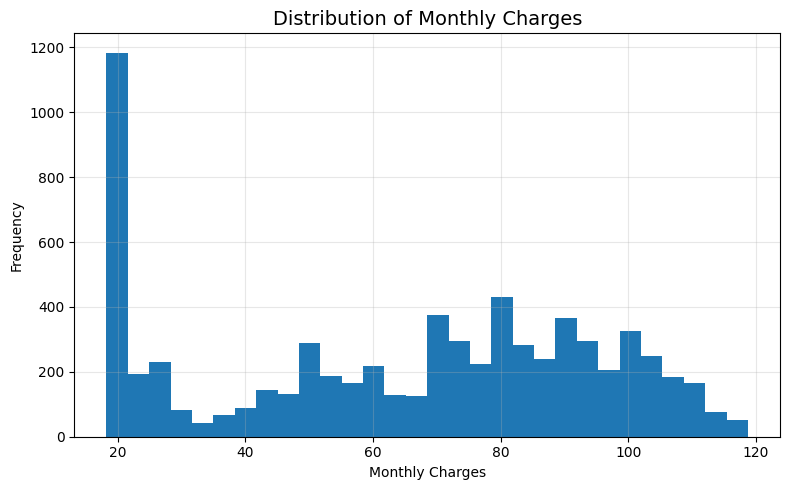

In [8]:
# Visualize distribution of MonthlyCharges
plt.figure(figsize=(8, 5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges", fontsize=14)
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 4. Total Charges Overview

`TotalCharges` is already numeric in the processed dataset.

In [9]:
print("TotalCharges statistics:")
print(f"  Min: {df['TotalCharges'].min():.2f}")
print(f"  Max: {df['TotalCharges'].max():.2f}")
print(f"  Mean: {df['TotalCharges'].mean():.2f}")
print(f"  Median: {df['TotalCharges'].median():.2f}")

TotalCharges statistics:
  Min: 18.80
  Max: 8684.80
  Mean: 2283.30
  Median: 1397.47


---

**Next step:** [02_eda_charges.ipynb](02_eda_charges.ipynb)
à¹„à¸›à¸•à¹ˆà¸­à¸—à¸µà¹ˆà¸à¸²à¸£à¸§à¸´à¹€à¸„à¸£à¸²à¸°à¸«à¹Œà¸„à¸§à¸²à¸¡à¸ªà¸±à¸¡à¸žà¸±à¸™à¸˜à¹Œà¸£à¸°à¸«à¸§à¹ˆà¸²à¸‡ charge structure à¹à¸¥à¸° churn.